# ITTE Conformal Prediction

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == "notebooks" else cwd
if repo.name == "tcda_uq":
    sys.path.insert(0, str(repo.parent))
elif (repo / "tcda_uq").exists():
    sys.path.insert(0, str(repo))

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

This notebook compares naive inverse-propensity conformal weighting
with overlap-stabilized weighting under weak overlap.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

from tcda_uq import evaluate_coverage
from tcda_uq.datasets import TriOracleSimulation
from tcda_uq.uq.conformal import ITTEConformal, make_weight_fn

In [3]:
sim = TriOracleSimulation(
    n_hom_dim=1,
    resolution=25,
    n_basis=5,
    noise_scale=0.3,
    prop_scale=3.0,
    seed=10,
)
train = sim.sample(360, rng=11)
test = sim.sample(160, rng=12)

models = {
    "naive": ITTEConformal.fit(
        train.observed,
        sim.tseq,
        n_basis=5,
        weight_fn=make_weight_fn("naive"),
        random_state=13,
        propensity_estimator=LogisticRegression(max_iter=500),
    ),
    "overlap": ITTEConformal.fit(
        train.observed,
        sim.tseq,
        n_basis=5,
        weight_fn=make_weight_fn("overlap"),
        random_state=13,
        propensity_estimator=LogisticRegression(max_iter=500),
    ),
}

In [4]:
rows = []
target = test.oracle_itte[:, 0, :]
for name, model in models.items():
    lo, hi, center = model.band_bounds(test.X, alpha=0.10, d=0)
    res = evaluate_coverage((lo, hi), target, level=0.90)
    finite = np.isfinite(hi - lo).all(axis=1)
    rows.append(
        {
            "weighting": name,
            "coverage": res.coverage,
            "finite_band_share": finite.mean(),
            "mean_width": res.mean_width,
        }
    )
pd.DataFrame(rows)

,weighting,coverage,finite_band_share,mean_width
0,naive,1.0,0.9375,inf
1,overlap,1.0,1.0000,3.751036


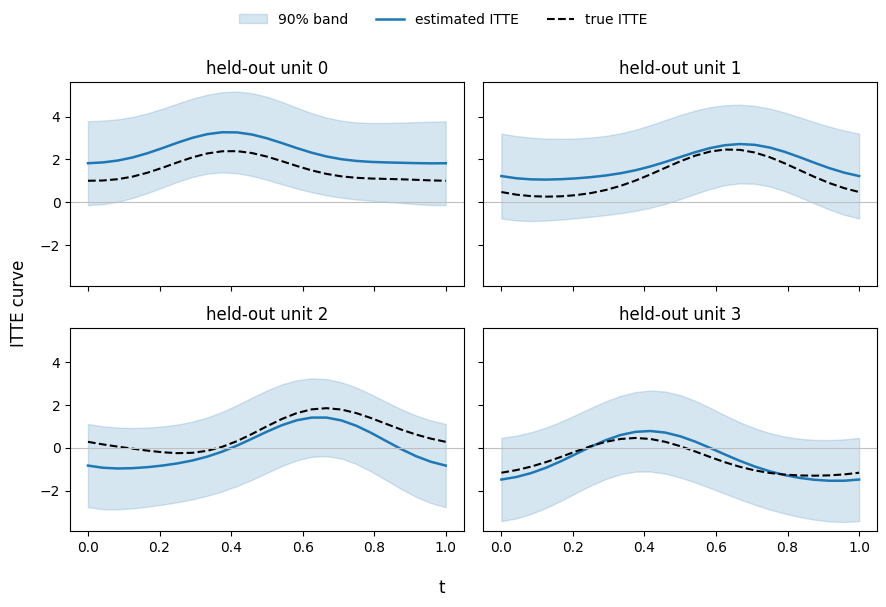

In [5]:
plot_idx = [0, 1, 2, 3]
lo, hi, center = models["overlap"].band_bounds(test.X[plot_idx], alpha=0.10, d=0)
true_itte = test.oracle_itte[plot_idx, 0, :]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
for ax, idx, lower, upper, ctr, truth in zip(
    axes.ravel(), plot_idx, lo, hi, center, true_itte
):
    ax.fill_between(sim.tseq, lower, upper, color="tab:blue", alpha=0.18, label="90% band")
    ax.plot(sim.tseq, ctr, color="tab:blue", lw=1.8, label="estimated ITTE")
    ax.plot(sim.tseq, truth, color="black", lw=1.5, linestyle="--", label="true ITTE")
    ax.set_title(f"held-out unit {idx}")
    ax.axhline(0.0, color="0.75", lw=0.8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.supxlabel("t")
fig.supylabel("ITTE curve")
fig.tight_layout(rect=(0, 0, 1, 0.93))